#### Link da tarefa:

- https://github.com/carlosadauto7/metodos-matematicos-2026.1/blob/main/tarefa_06/tarefa_06.ipynb

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

In [3]:
# (a), (b), (c), (d) - Dados de Entrada
expressao_f = 'log(x)'   # (a) Expressão da função f(x). Use 'log' para ln(x)
a = 1                    # (b) Centro a para os polinómios de Taylor
Kmin = 1                 # (c) Ordem mínima Kmin
Kmax = 5                 # (c) Ordem máxima Kmax (Kmax >= Kmin + 3)
xmin = -1                # (d) Limite inferior do gráfico (xmin < a)
xmax = 3                 # (d) Limite superior do gráfico (xmax > a)

# Controlo do Raio de Convergência Finito
R = 1.0                  # Raio de convergência para ln(x) centrado em 1 (deixe None se infinito)
delta = 0.05             # Margem pequena delta > 0

In [4]:
# Configuração simbólica
x = sp.Symbol('x')
f = sp.sympify(expressao_f)
f_num = sp.lambdify(x, f, 'numpy')

# Definição dos domínios
if R is not None:
    # f(x) apenas no intervalo fechado [a - R + delta, a + R - delta]
    x_vals_f = np.linspace(a - R + delta, a + R - delta, 400)
else:
    # f(x) em todo o intervalo [xmin, xmax]
    x_vals_f = np.linspace(xmin, xmax, 400)

# Polinómios avaliados sempre no intervalo completo [xmin, xmax]
x_vals_poly = np.linspace(xmin, xmax, 400)

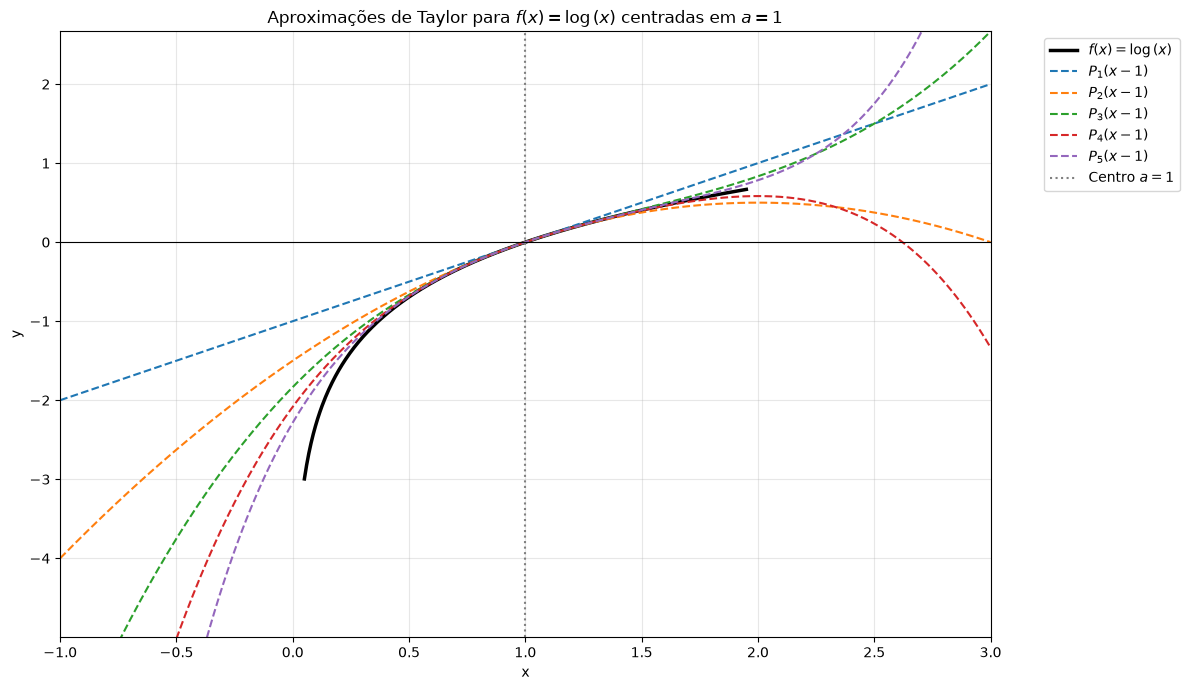

In [5]:
# Inicialização da figura
plt.figure(figsize=(12, 7))

# Traçar a função f(x)
y_vals_f = np.ones_like(x_vals_f) * f_num(x_vals_f)
plt.plot(x_vals_f, y_vals_f, label=f'$f(x) = {sp.latex(f)}$', color='black', linewidth=2.5)

# Cálculo iterativo e traçado dos polinómios de Taylor P_k(x-a)
for k in range(Kmin, Kmax + 1):
    taylor_poly = f.series(x, x0=a, n=k+1).removeO()
    poly_num = sp.lambdify(x, taylor_poly, 'numpy')
    
    # Avaliar o polinómio 
    y_vals_poly = np.ones_like(x_vals_poly) * poly_num(x_vals_poly)
    plt.plot(x_vals_poly, y_vals_poly, label=f'$P_{{{k}}}(x - {a})$', linestyle='--', linewidth=1.5)

# Formatação do gráfico
plt.xlim(xmin, xmax)
y_min, y_max = np.nanmin(y_vals_f), np.nanmax(y_vals_f)
plt.ylim(y_min - 2, y_max + 2)

plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(a, color='gray', linestyle=':', label=f'Centro $a={a}$')
plt.title(f'Aproximações de Taylor para $f(x) = {sp.latex(f)}$ centradas em $a={a}$')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Exibir o resultado
plt.show()

### Questão 2

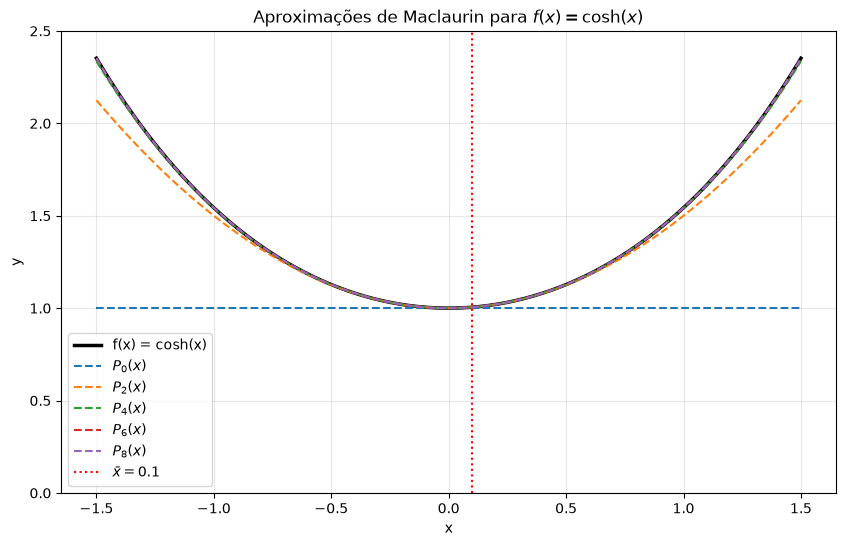

In [6]:
x = sp.Symbol('x')
f = sp.cosh(x)
f_num = sp.lambdify(x, f, 'numpy')

# Definição do domínio em torno de x = 0.1
x_vals = np.linspace(-1.5, 1.5, 400)
y_f = f_num(x_vals)

# Inicialização da figura
plt.figure(figsize=(10, 6))
plt.plot(x_vals, y_f, label='f(x) = cosh(x)', color='black', linewidth=2.5)

# Graus dos polinómios com coeficientes não nulos (0, 2, 4, 6, 8)
graus = [0, 2, 4, 6, 8]
for k in graus:
    poly = f.series(x, x0=0, n=k+1).removeO()
    poly_num = sp.lambdify(x, poly, 'numpy')
    
    y_poly = np.ones_like(x_vals) * poly_num(x_vals)
    plt.plot(x_vals, y_poly, label=f'$P_{{{k}}}(x)$', linestyle='--')

# Formatação
plt.axvline(0.1, color='red', linestyle=':', label='$\\bar{x} = 0.1$')
plt.ylim(0, 2.5)
plt.title('Aproximações de Maclaurin para $f(x) = \\cosh(x)$')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()